# Toolkit de refinamiento cuántico (k general) — experimento reproducible

Este notebook corre, con las funciones reales del toolkit (no un resumen ni una simulación),
todo lo que se reportó en el chat:

1. Los 3 tests de validación (QUBO genérico, factor de escala de R-QAOA, `exact` como oráculo).
2. Una corrida individual con reporte transparente por hotspot (qué ruta tomó el router y por qué).
3. Un barrido de varios grafos × escenarios × baselines, con la tabla y el gráfico de resultados.

**Requisitos:** el venv del repo (`QAOA-in-QAOA-Test/.venv`) con `requirements.txt` (raíz) +
`toolkit/requirements.txt` instalados. Ver `toolkit/README.md` y `toolkit/docs/ARCHITECTURE.md`
para el contexto completo y el diagrama de flujo del router.


## 0. Setup: ubicar la raíz del repo e importar el toolkit

In [1]:
import sys
from pathlib import Path

# Busca hacia arriba desde el directorio de trabajo actual la carpeta que
# contiene toolkit/pipeline.py -- robusto sin importar desde donde se abra
# el notebook (Jupyter classic, JupyterLab o VS Code pueden fijar el cwd
# distinto).
candidate = Path.cwd().resolve()
repo_root = None
for _ in range(5):
    if (candidate / "toolkit" / "pipeline.py").exists():
        repo_root = candidate
        break
    candidate = candidate.parent

if repo_root is None:
    raise RuntimeError(
        "No se encontro la raiz del repo (QAOA-in-QAOA-Test). "
        "Abre este notebook desde dentro del repo clonado."
    )

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

print("repo_root:", repo_root)


repo_root: C:\Users\srodrifa\Documents\GitHub\QAOA-in-QAOA-Test


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from toolkit.config import N_COLORS_REFERENCE, ToolkitConfig
from toolkit.pipeline import refine
from toolkit import _bootstrap  # noqa: F401  (pone src/ en sys.path)
from baselines.dsatur import dsatur
from baselines.greedy_coloring import greedy_coloring
from data.generate_graph import load_graph_scenario
from evaluation.cost_function import compute_interference_cost

BASELINES = {"greedy": greedy_coloring, "dsatur": dsatur}
DATA_DIR = repo_root / "data"

print("Valores de referencia de k (reuso celular clasico):")
for k, desc in N_COLORS_REFERENCE.items():
    print(f"  k={k}: {desc}")


Valores de referencia de k (reuso celular clasico):
  k=3: Reuse-3: patron hexagonal ajustado, alta capacidad, exige C/I alto.
  k=4: Reuse-4: patron citado en despliegues AMPS/GSM tempranos.
  k=7: Reuse-7: el ejemplo de manual del reuso hexagonal clasico.
  k=9: Reuse-9: GSM urbano denso con mayor tolerancia a interferencia.
  k=12: Reuse-12: baja reutilizacion, redes 2G de gran escala.


## 1. Validación básica

Las mismas tres verificaciones que se corrieron por consola antes de confiar en el resto del
kit — se importan y se corren aquí tal cual, no se re-escriben.


In [3]:
from toolkit.tests.test_toolkit import (
    test_qubo_matches_manual_cost,
    test_ising_adapter_scale,
    test_exact_is_oracle,
)

test_qubo_matches_manual_cost()
test_ising_adapter_scale()
test_exact_is_oracle()


test_qubo_matches_manual_cost: OK
test_ising_adapter_scale: OK


test_exact_is_oracle: OK (direct_qaoa y r_qaoa nunca superan al oraculo)


## 2. Una corrida individual, con el reporte transparente por hotspot

Carga un grafo real de `data/`, corre un baseline clásico, y refina con el toolkit. El reporte
muestra, por cada hotspot detectado, qué ruta tomó el router (`toolkit/router.py`) y por qué,
qué solver resolvió cada bloque, y el resultado de las dos estrategias de candidato
("individual", "swap").


In [4]:
def run_one(graph_name, scenario, baseline_name, k, seed=7):
    json_path = DATA_DIR / f"{graph_name}_{scenario}.json"
    graph = load_graph_scenario(str(json_path))
    baseline_fn = BASELINES[baseline_name]
    candidate = baseline_fn(graph, num_channels=k)
    baseline_cost = compute_interference_cost(graph, candidate)

    config = ToolkitConfig(n_colors=k, seed=seed)
    refined_coloring, report = refine(graph, candidate, k, config)
    return graph, candidate, baseline_cost, refined_coloring, report


def print_report(report):
    print(f"costo inicial: {report['initial_cost']:.2f}  |  densidad global: {report['global_density']:.3f}")
    print(f"hotspots detectados: {report['n_hotspots']}")
    for h in report["hotspots"]:
        estado = "ADOPTADO" if h["adopted"] else "descartado (no mejoro)"
        print(f"\n  hotspot {h['index']}: n={h['n']} densidad={h['density']} -> ruta={h['route']} [{estado}, delta={h['delta']:.2f}]")
        print(f"    razon de ruta: {h['reason']}")
        for b in h["blocks"]:
            tried_str = ", ".join(f"{t['strategy']}={t['cost']:.2f}" for t in b["tried"])
            print(f"    bloque n={b['n']} solver={b['solver']} ({b['reason']}) -> {tried_str}")
    print(f"\ncosto final: {report['final_cost']:.2f}  delta={report['delta_abs']:.2f} ({report['delta_pct']:+.2f}%)  nunca_empeora={report['never_worsens']}")


graph, candidate, baseline_cost, refined_coloring, report = run_one("sparse_100", "hora_pico", "dsatur", k=6)
print(f"grafo: sparse_100/hora_pico  |V|={graph.number_of_nodes()} |E|={graph.number_of_edges()}")
print(f"baseline: dsatur  costo={baseline_cost:.2f}\n")
print_report(report)


grafo: sparse_100/hora_pico  |V|=100 |E|=450
baseline: dsatur  costo=193.12

costo inicial: 193.12  |  densidad global: 0.091
hotspots detectados: 1

  hotspot 0: n=8 densidad=0.857 -> ruta=block_level [ADOPTADO, delta=17.94]
    razon de ruta: tamano 8 <= cap para densidad 0.86 (8)
    bloque n=8 solver=direct_qaoa (denso (densidad 0.86 >= 0.15)) -> individual=175.18, swap=193.12

costo final: 175.18  delta=17.94 (+9.29%)  nunca_empeora=True


## 3. Barrido: varios grafos × escenarios × baselines (k=6)

Reproduce la tabla de resultados completa mostrada en el chat. Cada combinación corre el
pipeline real — no hay números pre-calculados aquí. Con las 3 instancias de grafo × 2
escenarios × 2 baselines (12 corridas), puede tomar unos minutos porque
`realistic_metropolitan` tiene 600 nodos.


In [5]:
GRAPHS = ["sparse_100", "dense_100", "realistic_metropolitan"]
SCENARIOS = ["hora_pico", "hora_valle"]
K = 6

records = []
for graph_name in GRAPHS:
    for scenario in SCENARIOS:
        for baseline_name in BASELINES:
            _, _, baseline_cost, _, report = run_one(graph_name, scenario, baseline_name, k=K)
            records.append({
                "grafo": graph_name, "escenario": scenario, "baseline": baseline_name,
                "k": K, "costo_baseline": round(baseline_cost, 2),
                "costo_refinado": round(report["final_cost"], 2),
                "delta_pct": report["delta_pct"], "n_hotspots": report["n_hotspots"],
                "nunca_empeora": report["never_worsens"],
            })
            print(f"{graph_name:22s} {scenario:10s} {baseline_name:8s} -> "
                  f"delta={report['delta_pct']:+.2f}%  hotspots={report['n_hotspots']}")

df = pd.DataFrame(records)
df


sparse_100             hora_pico  greedy   -> delta=+4.93%  hotspots=2


sparse_100             hora_pico  dsatur   -> delta=+9.29%  hotspots=1
sparse_100             hora_valle greedy   -> delta=+14.45%  hotspots=2


sparse_100             hora_valle dsatur   -> delta=+20.14%  hotspots=1


dense_100              hora_pico  greedy   -> delta=+0.01%  hotspots=2


dense_100              hora_pico  dsatur   -> delta=+0.01%  hotspots=2


...

realistic_metropolitan hora_pico  greedy   -> delta=+4.73%  hotspots=4


realistic_metropolitan hora_pico  dsatur   -> delta=+3.22%  hotspots=4


realistic_metropolitan hora_valle greedy   -> delta=+5.14%  hotspots=4


realistic_metropolitan hora_valle dsatur   -> delta=+7.20%  hotspots=4


,grafo,escenario,baseline,k,costo_baseline,costo_refinado,delta_pct,n_hotspots,nunca_empeora
0,sparse_100,hora_pico,greedy,6,216.79,206.10,4.93,2,True
1,sparse_100,hora_pico,dsatur,6,193.12,175.18,9.29,1,True
2,sparse_100,hora_valle,greedy,6,89.05,76.18,14.45,2,True
3,sparse_100,hora_valle,dsatur,6,67.58,53.97,20.14,1,True
4,dense_100,hora_pico,greedy,6,3375.06,3374.88,0.01,2,True
5,dense_100,hora_pico,dsatur,6,3375.06,3374.88,0.01,2,True
6,dense_100,hora_valle,greedy,6,1466.76,1462.51,0.29,2,True
7,dense_100,hora_valle,dsatur,6,1466.76,1462.51,0.29,2,True
8,realistic_metropolitan,hora_pico,greedy,6,4044.31,3853.12,4.73,4,True
9,realistic_metropolitan,hora_pico,dsatur,6,4438.37,4295.43,3.22,4,True


In [6]:
assert df["nunca_empeora"].all(), "al menos una corrida empeoro -- revisar antes de seguir"
print("'nunca empeora' se cumplio en las", len(df), "corridas.")
df[["grafo", "escenario", "baseline", "costo_baseline", "costo_refinado", "delta_pct", "n_hotspots"]]


'nunca empeora' se cumplio en las 12 corridas.


,grafo,escenario,baseline,costo_baseline,costo_refinado,delta_pct,n_hotspots
0,sparse_100,hora_pico,greedy,216.79,206.10,4.93,2
1,sparse_100,hora_pico,dsatur,193.12,175.18,9.29,1
2,sparse_100,hora_valle,greedy,89.05,76.18,14.45,2
3,sparse_100,hora_valle,dsatur,67.58,53.97,20.14,1
4,dense_100,hora_pico,greedy,3375.06,3374.88,0.01,2
5,dense_100,hora_pico,dsatur,3375.06,3374.88,0.01,2
6,dense_100,hora_valle,greedy,1466.76,1462.51,0.29,2
7,dense_100,hora_valle,dsatur,1466.76,1462.51,0.29,2
8,realistic_metropolitan,hora_pico,greedy,4044.31,3853.12,4.73,4
9,realistic_metropolitan,hora_pico,dsatur,4438.37,4295.43,3.22,4


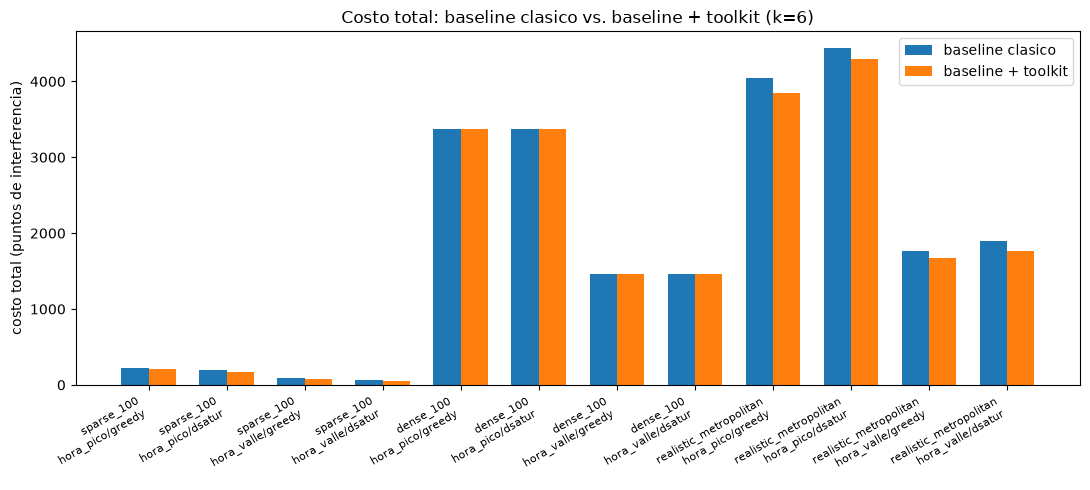

In [7]:
fig, ax = plt.subplots(figsize=(11, 5))
labels = [f"{r.grafo}\n{r.escenario}/{r.baseline}" for r in df.itertuples()]
x = range(len(df))
width = 0.35
ax.bar([i - width / 2 for i in x], df["costo_baseline"], width, label="baseline clasico")
ax.bar([i + width / 2 for i in x], df["costo_refinado"], width, label="baseline + toolkit")
ax.set_xticks(list(x))
ax.set_xticklabels(labels, fontsize=8, rotation=30, ha="right")
ax.set_ylabel("costo total (puntos de interferencia)")
ax.set_title("Costo total: baseline clasico vs. baseline + toolkit (k=6)")
ax.legend()
fig.tight_layout()
plt.show()


## 4. Siguiente paso

Para el diagrama de flujo completo del router (qué decide cada rombo y por qué) ver
[`toolkit/docs/ARCHITECTURE.md`](../docs/ARCHITECTURE.md). Para el estado de validación por
pieza (qué está probado a fondo vs. pendiente) ver [`toolkit/README.md`](../README.md) —
`r_qaoa` y `qaoa_square` todavía no tienen la misma validación exhaustiva por fuerza bruta a
escala real que la estrategia "swap" del proyecto original.
